# Sistema de Asignación de Órdenes de Producción
**Prueba Técnica · Módulo 1**  
**María Fernanda Hurtado**
---
### Metodología
El trabajo está organizado en seis fases. Cada una usa lo que produjo la anterior:

| Fase | Propósito |
|------|-----------|
| 1. Carga | Leer y conocer las cuatro fuentes de datos |
| 2. Exploración (EDA) | Entender el problema y detectar inconsistencias |
| 3. Preparación | Limpiar los datos y construir las variables del modelo |
| 4. Asignación | Optimizar qué taller fabrica qué material |
| 5. Secuenciación | Ordenar la producción de cada taller |
| 6. Escenarios What-if | Simular decisiones de negocio |

El problema tiene dos partes: **asignar** (qué taller fabrica qué, respetando capacidad,
especialización, experiencia e importancia) y **secuenciar** (en qué orden produce cada taller para
que las órdenes más prioritarias salgan primero).

### Archivos del proyecto
- `Modulo1_Solucion.ipynb` — este notebook, con todo el código reproducible.
- `Historial_de_ordenes (1) (2)/` — las cuatro fuentes de datos (CSV).

**Entorno:** Python 3.10 · pandas · numpy · PuLP (optimización) · matplotlib.

---
# Fase 1 · Carga de datos
Cargo las cuatro fuentes por separado y las dejo como tablas independientes. Solo las cruzo cuando
un análisis concreto lo necesita, para no arrastrar errores de una tabla a otra.

| Tabla | Contenido |
|-------|-----------|
| `Ordenes_de_trabajo.csv` | Órdenes a fabricar: unidades, material, prioridad y minutos |
| `Lista_de_proveedores.csv` | Talleres activos, su clasificación y los productos que manejan |
| `Historial_de_ordenes.csv` | Producción pasada de cada proveedor |
| `Capacidad_de_proveedores.csv` | Minutos disponibles por proveedor |

> La celda 6 muestra las primeras filas de cada tabla.

In [ ]:
# --- Importamos las librerías base del análisis ---
import pandas as pd   
import numpy as np    
from pathlib import Path
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker


# Configuración para que pandas muestre las tablas de forma cómoda y legible
pd.set_option('display.max_columns', None)   
pd.set_option('display.width', 120)           
pd.set_option('display.float_format', lambda x: f'{x:,.2f}') 

In [2]:
CARPETA_DATOS = Path('Historial_de_ordenes (1) (2)')

ruta_ordenes     = CARPETA_DATOS / 'Ordenes_de_trabajo.csv'
ruta_proveedores = CARPETA_DATOS / 'Lista_de_proveedores.csv'
ruta_historial   = CARPETA_DATOS / 'Historial_de_ordenes.csv'
ruta_capacidad   = CARPETA_DATOS / 'Capacidad_de_proveedores.csv'


In [3]:
# leemos cada una de las bd con pandas
df_ordenes     = pd.read_csv(ruta_ordenes)
df_proveedores = pd.read_csv(ruta_proveedores)
df_historial   = pd.read_csv(ruta_historial)
df_capacidad   = pd.read_csv(ruta_capacidad)

print('Las 4 tablas se cargaron en memoria.')

Las 4 tablas se cargaron en memoria.


In [4]:

# Esto confirma que la carga fue correcta y nos da una idea del tamaño de cada fuente.
resumen_dim = pd.DataFrame({
    'Tabla': ['Órdenes de trabajo', 'Lista de proveedores', 'Historial de órdenes', 'Capacidad de proveedores'],
    'Filas': [len(df_ordenes), len(df_proveedores), len(df_historial), len(df_capacidad)],
    'Columnas': [df_ordenes.shape[1], df_proveedores.shape[1], df_historial.shape[1], df_capacidad.shape[1]],
})
resumen_dim

,Tabla,Filas,Columnas
0,Órdenes de trabajo,802,7
1,Lista de proveedores,299,3
2,Historial de órdenes,39162,3
3,Capacidad de proveedores,211,2


### Primer vistazo a cada tabla

Se muestran las primeras filas de cada fuente para familiarizarse con sus columnas.

In [5]:
# 1) Órdenes de trabajo: lo que hay que producir
print('ÓRDENES DE TRABAJO')
df_ordenes.head()

ÓRDENES DE TRABAJO


,Orden,Unidades de la OP,Material,Denominacion Tipo de producto,SAM,Prioridad,Minutos totales de la orden
0,2690063,410.00,2690063,CHAQUETA DENIM,19.90,1.00,"8,157.36"
1,2690077,288.00,2690077,PUNTO BASICO,7.73,3.00,"2,227.39"
2,2690408,216.00,2690408,PUNTO BASICO,10.93,3.00,"2,361.53"
3,2690444,"2,240.00",2690444,PUNTO BASICO,8.97,3.00,"20,090.56"
4,2690496,653.00,2690496,PUNTO BASICO,11.80,3.00,"7,702.14"


In [6]:
# 2) Lista de proveedores: quién puede producir y su clasificación
print('LISTA DE PROVEEDORES')
df_proveedores.head()

LISTA DE PROVEEDORES


,ID,Descripcion clasificacion proveedor,Denominacion Tipo de producto
0,0,Acompañamiento,PUNTO MODA ESPECIAL
1,0,Acompañamiento,PUNTO CHAQUETA
2,1,Potenciales,BLUSA Y VESTID PLANO
3,2,Potenciales,OVEROL
4,3,Potenciales,PUNTO CHAQUETA


In [7]:
# 3) Historial de órdenes: experiencia pasada por proveedor y material
print('HISTORIAL DE ÓRDENES')
df_historial.head()

HISTORIAL DE ÓRDENES


,ID,Material,Unidades fabricadas
0,5,500063,414
1,140,500063,462
2,42,500063,552
3,101,500063,450
4,84,500261,354


In [8]:
# 4) Capacidad de proveedores: minutos disponibles por proveedor
print('CAPACIDAD DE PROVEEDORES')
df_capacidad.head()

CAPACIDAD DE PROVEEDORES


,ID,Capacidad Disponible
0,0,0
1,1,0
2,2,0
3,3,5218
4,4,0


---
# Fase 2 · Exploración de datos (EDA)
Revision de la calidad de los datos antes de modelar: tipos, nulos, duplicados, cuántos proveedores hay
de verdad y cómo se relacionan las tablas entre si

### 2.1 · Salud de las tablas: tipos, nulos y duplicados

In [9]:
# Salud de la tabla de ÓRDENES
print('ÓRDENES DE TRABAJO')
df_ordenes.info()

ÓRDENES DE TRABAJO
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 802 entries, 0 to 801
Data columns (total 7 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Orden                          802 non-null    int64  
 1   Unidades de la OP              802 non-null    float64
 2   Material                       802 non-null    int64  
 3   Denominacion Tipo de producto  802 non-null    object 
 4   SAM                            802 non-null    float64
 5   Prioridad                      802 non-null    float64
 6   Minutos totales de la orden    802 non-null    float64
dtypes: float64(4), int64(2), object(1)
memory usage: 44.0+ KB


In [10]:
# Salud de la tabla de PROVEEDORES
print('LISTA DE PROVEEDORES')
df_proveedores.info()

LISTA DE PROVEEDORES
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 299 entries, 0 to 298
Data columns (total 3 columns):
 #   Column                               Non-Null Count  Dtype 
---  ------                               --------------  ----- 
 0   ID                                   299 non-null    int64 
 1   Descripcion clasificacion proveedor  299 non-null    object
 2   Denominacion Tipo de producto        299 non-null    object
dtypes: int64(1), object(2)
memory usage: 7.1+ KB


In [11]:
# Salud de la tabla de HISTORIAL
print('HISTORIAL DE ÓRDENES')
df_historial.info()

HISTORIAL DE ÓRDENES
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 39162 entries, 0 to 39161
Data columns (total 3 columns):
 #   Column               Non-Null Count  Dtype
---  ------               --------------  -----
 0   ID                   39162 non-null  int64
 1   Material             39162 non-null  int64
 2   Unidades fabricadas  39162 non-null  int64
dtypes: int64(3)
memory usage: 918.0 KB


In [12]:
# Salud de la tabla de CAPACIDAD
print('CAPACIDAD DE PROVEEDORES')
df_capacidad.info()

CAPACIDAD DE PROVEEDORES
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 211 entries, 0 to 210
Data columns (total 2 columns):
 #   Column                Non-Null Count  Dtype
---  ------                --------------  -----
 0   ID                    211 non-null    int64
 1   Capacidad Disponible  211 non-null    int64
dtypes: int64(2)
memory usage: 3.4 KB


In [13]:
# Resumen de nulos y filas duplicadas por tabla
def resumen_calidad(nombre, df):
    return {
        "Tabla": nombre,
        "Filas": len(df),
        "Columnas": df.shape[1],
        "Celdas nulas (total)": int(df.isna().sum().sum()),
        "Filas duplicadas": int(df.duplicated().sum()),
    }

tabla_calidad = pd.DataFrame([
    resumen_calidad("Órdenes", df_ordenes),
    resumen_calidad("Proveedores", df_proveedores),
    resumen_calidad("Historial", df_historial),
    resumen_calidad("Capacidad", df_capacidad),
])
tabla_calidad

,Tabla,Filas,Columnas,Celdas nulas (total),Filas duplicadas
0,Órdenes,802,7,0,0
1,Proveedores,299,3,0,8
2,Historial,39162,3,0,0
3,Capacidad,211,2,0,0


### 2.2 · Proveedores reales y capacidad disponible

In [14]:
# Proveedores únicos en la lista (por ID)
proveedores_unicos = df_proveedores["ID"].nunique()
print(f"Filas en lista de proveedores : {len(df_proveedores)}")
print(f"Proveedores únicos (por ID)   : {proveedores_unicos}")

# Promedio de tipos de producto por proveedor
tipos_por_prov = df_proveedores.groupby("ID").size()
print(f"Tipos de producto por proveedor -> min={tipos_por_prov.min()}, "
      f"max={tipos_por_prov.max()}, promedio={tipos_por_prov.mean():.2f}")

Filas en lista de proveedores : 299
Proveedores únicos (por ID)   : 211
Tipos de producto por proveedor -> min=1, max=7, promedio=1.42


In [15]:
# Capacidad: ¿cuántos proveedores tienen capacidad > 0?
total_cap = len(df_capacidad)
con_capacidad = (df_capacidad["Capacidad Disponible"] > 0).sum()
sin_capacidad = (df_capacidad["Capacidad Disponible"] == 0).sum()

print(f"Proveedores en tabla de capacidad : {total_cap}")
print(f"  - Con capacidad > 0             : {con_capacidad}")
print(f"  - Con capacidad = 0             : {sin_capacidad}")
print()
print("Estadísticas de la capacidad (solo > 0):")
df_capacidad.loc[df_capacidad["Capacidad Disponible"] > 0, "Capacidad Disponible"].describe()

Proveedores en tabla de capacidad : 211
  - Con capacidad > 0             : 127
  - Con capacidad = 0             : 84

Estadísticas de la capacidad (solo > 0):


count      127.00
mean    15,340.04
std     13,349.13
min        298.00
25%      5,381.50
50%     11,474.00
75%     20,698.50
max     68,282.00
Name: Capacidad Disponible, dtype: float64

### 2.3 · Clasificación de importancia de los proveedores

In [16]:
# Categorías de clasificación existentes (contando proveedores únicos por categoría)
clasif = (df_proveedores[["ID", "Descripcion clasificacion proveedor"]]
          .drop_duplicates()
          .groupby("Descripcion clasificacion proveedor")["ID"]
          .nunique()
          .sort_values(ascending=False))
print("Proveedores únicos por categoría de clasificación:")
clasif

Proveedores únicos por categoría de clasificación:


Descripcion clasificacion proveedor
Oportunidad       134
Potenciales        68
Confianza           8
Acompañamiento      1
Name: ID, dtype: int64

La estructura es piramidal: las categorías de mayor confianza son también las más escasas.

In [ ]:
DIR_GRAFICOS = Path("graficos")
DIR_GRAFICOS.mkdir(exist_ok=True)

plt.rcParams.update({
    "figure.dpi": 110,
    "savefig.dpi": 130,
    "font.size": 11,
    "axes.titlesize": 13,
    "axes.titleweight": "bold",
    "axes.spines.top": False,
    "axes.spines.right": False,
})
AZUL = "#2a5a9e"; NARANJA = "#e08a3c"; VERDE = "#3c9e6a"; ROJO = "#c0504d"; GRIS = "#9aa5b1"

def guardar(fig, nombre):
    ruta = DIR_GRAFICOS / nombre
    fig.savefig(ruta, bbox_inches="tight")
    print("Guardado:", ruta)

Entorno de gráficos listo.


Guardado: graficos/g3_clasificacion.png


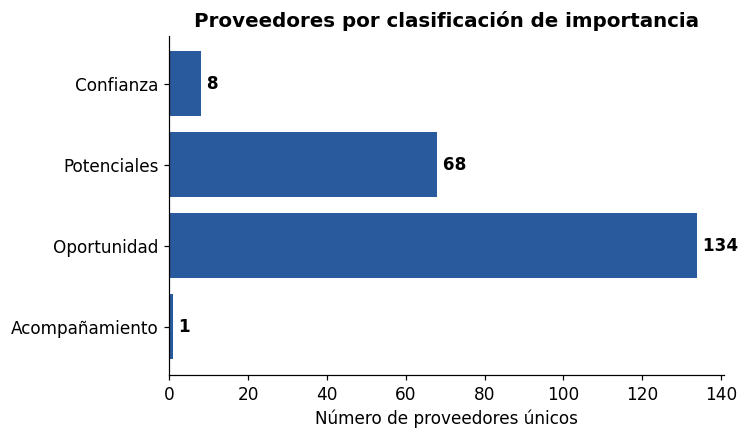

In [18]:
clasif_cnt = (df_proveedores[["ID", "Descripcion clasificacion proveedor"]].drop_duplicates()
              .groupby("Descripcion clasificacion proveedor")["ID"].nunique()
              .reindex(["Confianza", "Potenciales", "Oportunidad", "Acompañamiento"]))
fig, ax = plt.subplots(figsize=(6.5, 4))
barras = ax.barh(clasif_cnt.index[::-1], clasif_cnt.values[::-1], color=AZUL)
ax.set_xlabel("Número de proveedores únicos")
ax.set_title("Proveedores por clasificación de importancia")
for b, v in zip(barras, clasif_cnt.values[::-1]):
    ax.text(v, b.get_y()+b.get_height()/2, f" {v}", va="center", fontweight="bold")
guardar(fig, "g3_clasificacion.png")
plt.show()

La categoría "Oportunidad" concentra la mayoría de los talleres (134), mientras que Confianza y Acompañamiento son minoritarias. Los proveedores de mayor nivel son, entonces, un recurso escaso.

### 2.4 · Características de las órdenes

In [19]:
# Distribución de prioridades (1 = menos importante, 3 = más importante)
print("Órdenes por prioridad:")
print(df_ordenes["Prioridad"].value_counts().sort_index())
print()
print("Estadísticas de 'Minutos totales de la orden':")
df_ordenes["Minutos totales de la orden"].describe()

Órdenes por prioridad:
Prioridad
1.00      1
2.00     24
3.00    777
Name: count, dtype: int64

Estadísticas de 'Minutos totales de la orden':


count      802.00
mean     4,229.67
std      3,480.74
min        469.16
25%      2,114.65
50%      3,293.76
75%      5,273.00
max     25,381.68
Name: Minutos totales de la orden, dtype: float64

In [20]:
# Tipos de producto más frecuentes en las órdenes
print(f"Tipos de producto distintos en órdenes: {df_ordenes['Denominacion Tipo de producto'].nunique()}")
print()
print("Top 10 tipos de producto por número de órdenes:")
df_ordenes["Denominacion Tipo de producto"].value_counts().head(10)

Tipos de producto distintos en órdenes: 19

Top 10 tipos de producto por número de órdenes:


Denominacion Tipo de producto
PUNTO BASICO              439
PUNTO INTERIOR            123
PANTY Y TOP                62
PUNTO BASICO TRAFICO       56
BRASIER                    25
INFERIORES PLANO           19
PUNTO INTERIOR TRAFICO     15
CAMISA LIVIANO             10
BLUSA Y VESTID PLANO        9
INFERIOR DENIM              9
Name: count, dtype: int64

La distribución de prioridades muestra un fuerte desbalance:

Guardado: graficos/g2_prioridades.png


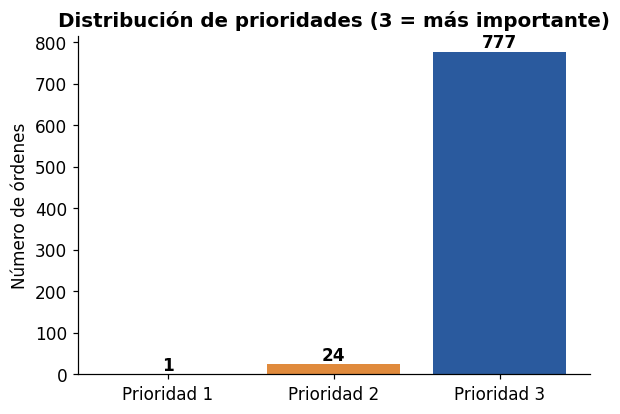

In [21]:
conteo_prio = df_ordenes["Prioridad"].value_counts().sort_index()

fig, ax = plt.subplots(figsize=(6, 4))
barras = ax.bar([f"Prioridad {int(p)}" for p in conteo_prio.index], conteo_prio.values,
                color=[GRIS, NARANJA, AZUL])
ax.set_ylabel("Número de órdenes")
ax.set_title("Distribución de prioridades (3 = más importante)")
for b, v in zip(barras, conteo_prio.values):
    ax.text(b.get_x()+b.get_width()/2, v, str(v), ha="center", va="bottom", fontweight="bold")
guardar(fig, "g2_prioridades.png")
plt.show()

777 de 802 órdenes son prioridad 3. Como casi todas tienen la misma prioridad, esta variable discrimina poco en la asignación, pero sí es decisiva en la secuenciación (Fase 5).

### 2.5 · Relación entre las tablas (códigos de material)

Se comprueba si los códigos de material de las órdenes coinciden con los del historial, para saber si
las tablas pueden cruzarse por esa clave.

In [22]:
# Comparamos los conjuntos de códigos de material de ambas tablas
materiales_ordenes = set(df_ordenes["Material"].unique())
materiales_historial = set(df_historial["Material"].unique())
interseccion = materiales_ordenes & materiales_historial

print(f"Materiales únicos en ÓRDENES   : {len(materiales_ordenes)}")
print(f"Materiales únicos en HISTORIAL : {len(materiales_historial)}")
print(f"Materiales en común            : {len(interseccion)}")
print()
print("Ejemplos de material en ÓRDENES  :", sorted(list(materiales_ordenes))[:5])
print("Ejemplos de material en HISTORIAL:", sorted(list(materiales_historial))[:5])

Materiales únicos en ÓRDENES   : 802
Materiales únicos en HISTORIAL : 10738
Materiales en común            : 0

Ejemplos de material en ÓRDENES  : [2690063, 2690077, 2690408, 2690444, 2690496]
Ejemplos de material en HISTORIAL: [500063, 500261, 500466, 500519, 500849]


El tipo de producto, presente tanto en órdenes como en proveedores, es la clave de cruce alternativa. Se verifica su cobertura.

In [23]:
# ¿Coinciden los tipos de producto entre órdenes y proveedores?
tipos_ordenes = set(df_ordenes["Denominacion Tipo de producto"].str.strip().unique())
tipos_proveedores = set(df_proveedores["Denominacion Tipo de producto"].str.strip().unique())

print(f"Tipos de producto en ÓRDENES      : {len(tipos_ordenes)}")
print(f"Tipos de producto en PROVEEDORES  : {len(tipos_proveedores)}")
print(f"Tipos en común                    : {len(tipos_ordenes & tipos_proveedores)}")
print()
# Tipos de producto que piden las órdenes pero que NINGÚN proveedor declara manejar
tipos_sin_proveedor = tipos_ordenes - tipos_proveedores
print(f"Tipos de producto pedidos SIN proveedor que los maneje: {len(tipos_sin_proveedor)}")
if tipos_sin_proveedor:
    print("Ejemplos:", sorted(list(tipos_sin_proveedor))[:10])

Tipos de producto en ÓRDENES      : 19
Tipos de producto en PROVEEDORES  : 22
Tipos en común                    : 18

Tipos de producto pedidos SIN proveedor que los maneje: 1
Ejemplos: ['PUNTO INTERIOR TRAFICO']


### 2.6 · Relación entre demanda y capacidad

In [24]:
# Demanda total vs capacidad total
demanda_total = df_ordenes["Minutos totales de la orden"].sum()
capacidad_total = df_capacidad.loc[df_capacidad["Capacidad Disponible"] > 0, "Capacidad Disponible"].sum()

print(f"Demanda total (minutos de todas las órdenes) : {demanda_total:,.0f}")
print(f"Capacidad total disponible (minutos)         : {capacidad_total:,.0f}")
print(f"Ratio demanda / capacidad                    : {demanda_total / capacidad_total:,.2f}")
print()
if demanda_total > capacidad_total:
    print("=> La demanda SUPERA la capacidad: es IMPOSIBLE atender todas las órdenes.")
    print("   Esto confirma que el problema es de OPTIMIZACIÓN (maximizar el valor de lo que sí se puede producir).")
else:
    print("=> La capacidad alcanza para la demanda total (en agregado).")
    print("   Aun así, las restricciones de especialización y la regla 'material completo' pueden impedir asignar todo.")

Demanda total (minutos de todas las órdenes) : 3,392,195
Capacidad total disponible (minutos)         : 1,948,185
Ratio demanda / capacidad                    : 1.74

=> La demanda SUPERA la capacidad: es IMPOSIBLE atender todas las órdenes.
   Esto confirma que el problema es de OPTIMIZACIÓN (maximizar el valor de lo que sí se puede producir).


La comparación entre lo que se necesita producir y lo que se puede producir:

Guardado: graficos/g1_demanda_vs_capacidad.png


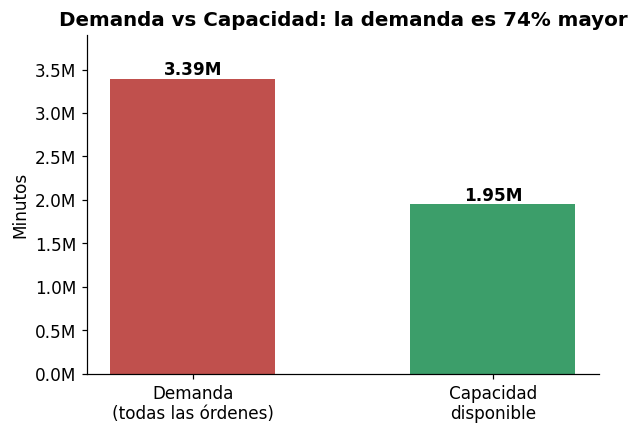

In [25]:
demanda = df_ordenes["Minutos totales de la orden"].sum()
cap_tot = df_capacidad.loc[df_capacidad["Capacidad Disponible"] > 0, "Capacidad Disponible"].sum()

fig, ax = plt.subplots(figsize=(6, 4))
barras = ax.bar(["Demanda\n(todas las órdenes)", "Capacidad\ndisponible"],
                [demanda, cap_tot], color=[ROJO, VERDE], width=0.55)
ax.set_ylabel("Minutos")
ax.set_ylim(0, demanda * 1.15)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x/1e6:.1f}M"))
for b, v in zip(barras, [demanda, cap_tot]):
    ax.text(b.get_x()+b.get_width()/2, v, f"{v/1e6:.2f}M", ha="center", va="bottom", fontweight="bold")
ax.set_title(f"Demanda vs Capacidad: la demanda es {demanda/cap_tot-1:.0%} mayor")
guardar(fig, "g1_demanda_vs_capacidad.png")
plt.show()

La demanda supera a la capacidad en un 74%: solo cabe el 57% del trabajo. No se puede producir todo, así que el problema es decidir qué producir, no cómo repartirlo.

---
# Fase 3 · Preparación de los datos

Se limpian las tablas y se construyen las variables que alimentarán el modelo. Las decisiones de
negocio se centralizan en una celda de parámetros, que luego permite simular escenarios.

### 3.1 · Parámetros del modelo

Todas las decisiones ajustables del análisis se reúnen aquí, en un único lugar.

In [ ]:

# (a) Orden de importancia de las categorías de proveedor.
#     Número más alto = más importante. Es una hipótesis de negocio, editable.
PESO_CLASIFICACION = {
    "Confianza": 4,
    "Potenciales": 3,
    "Oportunidad": 2,
    "Acompañamiento": 1,
}
#     True  -> "PUNTO INTERIOR TRAFICO" lo pueden hacer proveedores de "PUNTO INTERIOR" (rescata 15 órdenes P3).
#     False -> las variantes TRAFICO sin proveedor quedan como NO asignables.
HOMOLOGAR_TRAFICO = True

#     "total_a_cada_tipo"  -> se le atribuye su producción total a cada tipo que maneja (simple y robusto).
#     "proporcional_igual" -> se reparte el total en partes iguales entre sus tipos.
MODO_EXPERIENCIA_MULTITIPO = "total_a_cada_tipo"

print("Parámetros cargados:")
print("  PESO_CLASIFICACION         =", PESO_CLASIFICACION)
print("  HOMOLOGAR_TRAFICO          =", HOMOLOGAR_TRAFICO)
print("  MODO_EXPERIENCIA_MULTITIPO =", MODO_EXPERIENCIA_MULTITIPO)

Parámetros cargados:
  PESO_CLASIFICACION         = {'Confianza': 4, 'Potenciales': 3, 'Oportunidad': 2, 'Acompañamiento': 1}
  HOMOLOGAR_TRAFICO          = True
  MODO_EXPERIENCIA_MULTITIPO = total_a_cada_tipo


### 3.2 · Limpieza de las tablas

Se trabaja sobre copias para no alterar los datos originales. Se normaliza el texto de los tipos de producto y se eliminan filas duplicadas.

In [27]:
# Copias de trabajo (no tocamos los originales)
ordenes = df_ordenes.copy()
proveedores = df_proveedores.copy()
historial = df_historial.copy()
capacidad = df_capacidad.copy()

# 1) Normalizar texto de "Tipo de producto": quitar espacios al inicio/fin y unificar mayúsculas
for d in (ordenes, proveedores):
    d["Denominacion Tipo de producto"] = d["Denominacion Tipo de producto"].str.strip().str.upper()

# 2) Eliminar duplicados exactos en la lista de proveedores
antes = len(proveedores)
proveedores = proveedores.drop_duplicates().reset_index(drop=True)
print(f"Proveedores: {antes} filas -> {len(proveedores)} filas tras quitar duplicados")

# Renombramos columnas largas a nombres cortos y cómodos
proveedores = proveedores.rename(columns={
    "Descripcion clasificacion proveedor": "clasificacion",
    "Denominacion Tipo de producto": "tipo_producto",
})
ordenes = ordenes.rename(columns={
    "Denominacion Tipo de producto": "tipo_producto",
    "Minutos totales de la orden": "minutos",
    "Prioridad": "prioridad",
    "Unidades de la OP": "unidades",
})
capacidad = capacidad.rename(columns={"Capacidad Disponible": "capacidad"})
print("Columnas de órdenes    :", list(ordenes.columns))
print("Columnas de proveedores:", list(proveedores.columns))

Proveedores: 299 filas -> 291 filas tras quitar duplicados
Columnas de órdenes    : ['Orden', 'unidades', 'Material', 'tipo_producto', 'SAM', 'prioridad', 'minutos']
Columnas de proveedores: ['ID', 'clasificacion', 'tipo_producto']


### 3.3 · Homologación de variantes TRAFICO
Las variantes que terminan en "TRAFICO" se asocian a su tipo base cuando ese tipo sí tiene proveedores,
porque en la práctica es solo una diferencia de nombre. Conservo la columna original y creo una nueva
con el tipo elegible.

In [28]:
# Construimos el mapa de homologación: "<BASE> TRAFICO" -> "<BASE>"
tipos_proveedores = set(proveedores["tipo_producto"].unique())

def homologar(tp):
    """Devuelve el tipo base si corresponde homologar; si no, el mismo tipo."""
    if HOMOLOGAR_TRAFICO and tp.endswith(" TRAFICO"):
        base = tp[: -len(" TRAFICO")].strip()
        if base in tipos_proveedores:   # solo si el tipo base realmente lo maneja alguien
            return base
    return tp

ordenes["tipo_elegible"] = ordenes["tipo_producto"].apply(homologar)

# ¿Qué tipos se homologaron y cuántas órdenes afectó cada uno?
homologados = ordenes[ordenes["tipo_producto"] != ordenes["tipo_elegible"]]
print(f"Órdenes homologadas (TRAFICO -> base): {len(homologados)}")
if len(homologados):
    print(homologados.groupby(["tipo_producto", "tipo_elegible"]).size().rename("n_ordenes"))

Órdenes homologadas (TRAFICO -> base): 71
tipo_producto           tipo_elegible 
PUNTO BASICO TRAFICO    PUNTO BASICO      56
PUNTO INTERIOR TRAFICO  PUNTO INTERIOR    15
Name: n_ordenes, dtype: int64


### 3.4 · Proveedores elegibles por tipo de producto

Un proveedor es elegible para una orden si maneja ese tipo de producto y tiene capacidad disponible.

In [29]:
# Proveedores con capacidad > 0 (los únicos candidatos reales)
cap_positiva = capacidad[capacidad["capacidad"] > 0][["ID", "capacidad"]]

# Lista "proveedor -> tipo de producto que maneja" (solo con capacidad > 0)
prov_tipo = (proveedores.merge(cap_positiva, on="ID", how="inner")
                        [["ID", "clasificacion", "tipo_producto"]]
                        .drop_duplicates())

# Diagnóstico: ¿qué tipos pedidos por las órdenes tienen al menos un proveedor elegible?
tipos_pedidos = set(ordenes["tipo_elegible"].unique())
tipos_cubiertos = set(prov_tipo["tipo_producto"].unique())
sin_cobertura = tipos_pedidos - tipos_cubiertos

print(f"Tipos de producto pedidos (tras homologar): {len(tipos_pedidos)}")
print(f"Tipos con al menos un proveedor elegible  : {len(tipos_pedidos & tipos_cubiertos)}")
print(f"Tipos SIN proveedor elegible              : {len(sin_cobertura)}")
if sin_cobertura:
    print("  ->", sorted(sin_cobertura))

# Órdenes que quedan sin ningún proveedor posible
ordenes_sin_prov = ordenes[ordenes["tipo_elegible"].isin(sin_cobertura)]
print(f"\nÓrdenes NO asignables (ningún proveedor elegible): {len(ordenes_sin_prov)}")

Tipos de producto pedidos (tras homologar): 17
Tipos con al menos un proveedor elegible  : 13
Tipos SIN proveedor elegible              : 4
  -> ['CAMISA LIVIANO', 'CAMISA PLANO', 'CHAQUETA PLANO', 'OVEROL']

Órdenes NO asignables (ningún proveedor elegible): 27


### 3.5 · Experiencia por proveedor y tipo de producto
Como los códigos de material no cruzan entre tablas, reconstruyo la experiencia usando el ID del
proveedor: sumo su producción histórica y se la atribuyo a los tipos que maneja. Para los talleres
que manejan un solo tipo (la mayoría) la atribución es exacta. Después normalizo el valor dentro de
cada tipo para que las comparaciones sean justas.

In [30]:
# 1) Producción histórica total por proveedor
prod_total = historial.groupby("ID")["Unidades fabricadas"].sum().rename("unidades_hist")

# 2) Tipos que maneja cada proveedor (con capacidad > 0) y nº de tipos
tipos_por_prov = prov_tipo.groupby("ID")["tipo_producto"].apply(list)

filas_exp = []
for pid, tipos in tipos_por_prov.items():
    total = float(prod_total.get(pid, 0.0))   # 0 si el proveedor no aparece en el historial
    n = len(tipos)
    for tp in tipos:
        if MODO_EXPERIENCIA_MULTITIPO == "proporcional_igual" and n > 1:
            valor = total / n
        else:  # "total_a_cada_tipo"
            valor = total
        filas_exp.append({"ID": pid, "tipo_producto": tp, "experiencia": valor})

experiencia = pd.DataFrame(filas_exp)

# 3) Normalizar la experiencia a 0-1 DENTRO de cada tipo de producto.
#    Usamos transform (en vez de apply) para evitar el DeprecationWarning y ser más eficientes:
#    para cada fila, el máximo de experiencia de su tipo de producto.
max_por_tipo = experiencia.groupby("tipo_producto")["experiencia"].transform("max")
experiencia["experiencia_norm"] = (experiencia["experiencia"] / max_por_tipo).fillna(0.0)

print(f"Tabla de experiencia construida: {len(experiencia)} pares (proveedor, tipo)")
print("\nEjemplo (PUNTO INTERIOR, ordenado por experiencia):")
print(experiencia[experiencia["tipo_producto"] == "PUNTO INTERIOR"]
      .sort_values("experiencia_norm", ascending=False)
      .head(8).to_string(index=False))

Tabla de experiencia construida: 168 pares (proveedor, tipo)

Ejemplo (PUNTO INTERIOR, ordenado por experiencia):
 ID  tipo_producto  experiencia  experiencia_norm
 90 PUNTO INTERIOR 1,868,198.00              1.00
 55 PUNTO INTERIOR   816,882.00              0.44
138 PUNTO INTERIOR   706,278.00              0.38
125 PUNTO INTERIOR   482,006.00              0.26
115 PUNTO INTERIOR   470,188.00              0.25
142 PUNTO INTERIOR   366,224.00              0.20
 71 PUNTO INTERIOR   359,680.00              0.19
 66 PUNTO INTERIOR   340,160.00              0.18


### 3.6 · Importancia del proveedor según su clasificación

In [31]:
# Un proveedor = una clasificación (lo verificamos en la Fase 2), así que tomamos la primera
clasif_prov = proveedores[["ID", "clasificacion"]].drop_duplicates(subset="ID").copy()
clasif_prov["peso_clasif"] = clasif_prov["clasificacion"].map(PESO_CLASIFICACION)

# Normalizar a 0-1 (dividiendo por el peso máximo posible)
max_peso = max(PESO_CLASIFICACION.values())
clasif_prov["clasif_norm"] = clasif_prov["peso_clasif"] / max_peso

print("Score de importancia por categoría:")
print(clasif_prov.groupby("clasificacion")[["peso_clasif", "clasif_norm"]].first()
      .sort_values("peso_clasif", ascending=False))

Score de importancia por categoría:
                peso_clasif  clasif_norm
clasificacion                           
Confianza                 4         1.00
Potenciales               3         0.75
Oportunidad               2         0.50
Acompañamiento            1         0.25


### 3.7 · Chequeos de integridad

Se verifica que ninguna transformación haya perdido o alterado datos por error.

In [32]:
print("===== CHEQUEOS DE INTEGRIDAD =====")
# 1) No se perdió ninguna orden
assert len(ordenes) == len(df_ordenes), "¡Se perdieron o duplicaron órdenes!"
print(f"[OK] Órdenes intactas: {len(ordenes)}")

# 2) La homologación no inventó tipos que no existían
assert ordenes["tipo_elegible"].notna().all(), "Hay tipo_elegible nulo"
print(f"[OK] Todas las órdenes tienen tipo_elegible")

# 3) Resumen de asignabilidad
asignables = ordenes[~ordenes["tipo_elegible"].isin(sin_cobertura)]
no_asign = ordenes[ordenes["tipo_elegible"].isin(sin_cobertura)]
print(f"[OK] Órdenes potencialmente asignables : {len(asignables)} "
      f"({len(asignables)/len(ordenes)*100:.1f}%)")
print(f"[OK] Órdenes NO asignables             : {len(no_asign)} "
      f"({no_asign['minutos'].sum():,.0f} minutos)")

# 4) Experiencia: cada par (proveedor, tipo) corresponde a un proveedor elegible
assert set(experiencia["ID"]).issubset(set(prov_tipo["ID"])), "Experiencia con proveedores no elegibles"
print(f"[OK] Experiencia coherente con proveedores elegibles")

print("\n==> Fase 3 completada: datos limpios y piezas del modelo listas.")

===== CHEQUEOS DE INTEGRIDAD =====
[OK] Órdenes intactas: 802
[OK] Todas las órdenes tienen tipo_elegible
[OK] Órdenes potencialmente asignables : 775 (96.6%)
[OK] Órdenes NO asignables             : 27 (196,366 minutos)
[OK] Experiencia coherente con proveedores elegibles

==> Fase 3 completada: datos limpios y piezas del modelo listas.


### 3.8 · Órdenes no asignables

Algunas órdenes corresponden a tipos de producto cuyos únicos proveedores tienen capacidad cero. Se
identifican y documentan: no es una limitación del método, sino de la capacidad disponible.

In [33]:
# Tabla formal de órdenes NO asignables (escenario base)
ordenes_no_asignables = ordenes[ordenes["tipo_elegible"].isin(sin_cobertura)].copy()

resumen_no_asign = (ordenes_no_asignables
                    .groupby("tipo_elegible")
                    .agg(n_ordenes=("Orden", "size"),
                         minutos=("minutos", "sum"),
                         prioridad_media=("prioridad", "mean"))
                    .sort_values("n_ordenes", ascending=False))

print("Resumen de órdenes NO asignables por tipo de producto:")
print(resumen_no_asign.to_string())
print(f"\nTotal: {len(ordenes_no_asignables)} órdenes | "
      f"{ordenes_no_asignables['minutos'].sum():,.0f} minutos | "
      f"{ordenes_no_asignables['minutos'].sum()/ordenes['minutos'].sum()*100:.1f}% de la demanda total")

Resumen de órdenes NO asignables por tipo de producto:
                n_ordenes   minutos  prioridad_media
tipo_elegible                                       
CAMISA LIVIANO         10 42,994.64             3.00
CAMISA PLANO            8 55,129.88             3.00
OVEROL                  5 86,035.20             2.00
CHAQUETA PLANO          4 12,206.72             3.00

Total: 27 órdenes | 196,366 minutos | 5.8% de la demanda total


### 3.9 · Conjunto final de órdenes a optimizar

In [34]:
# Conjunto que entra al modelo
ordenes_asignables = ordenes[~ordenes["tipo_elegible"].isin(sin_cobertura)].copy()

print("===== RESUMEN FINAL DE LA FASE 3 =====")
print(f"Órdenes totales            : {len(ordenes)}")
print(f"  -> Asignables (al modelo): {len(ordenes_asignables)} ({len(ordenes_asignables)/len(ordenes)*100:.1f}%)")
print(f"  -> No asignables         : {len(ordenes_no_asignables)} ({len(ordenes_no_asignables)/len(ordenes)*100:.1f}%)")
print()
print(f"Proveedores candidatos (capacidad > 0): {prov_tipo['ID'].nunique()}")
print(f"Tipos de producto a cubrir            : {ordenes_asignables['tipo_elegible'].nunique()}")
print(f"Demanda asignable (minutos)           : {ordenes_asignables['minutos'].sum():,.0f}")
print(f"Capacidad total disponible (minutos)  : {cap_positiva['capacidad'].sum():,.0f}")
print("\nPiezas listas para la Fase 4: ordenes_asignables, prov_tipo, experiencia, clasif_prov, cap_positiva")

===== RESUMEN FINAL DE LA FASE 3 =====
Órdenes totales            : 802
  -> Asignables (al modelo): 775 (96.6%)
  -> No asignables         : 27 (3.4%)

Proveedores candidatos (capacidad > 0): 127
Tipos de producto a cubrir            : 13
Demanda asignable (minutos)           : 3,195,828
Capacidad total disponible (minutos)  : 1,948,185

Piezas listas para la Fase 4: ordenes_asignables, prov_tipo, experiencia, clasif_prov, cap_positiva


---
# Fase 4 · Modelo de asignación

Se formula un modelo de optimización (programación lineal entera) que decide qué taller fabrica cada
material, maximizando el valor total de la producción y respetando capacidad, especialización y la
regla de material completo.

### 4.1 · Pesos de la función de valor

El valor de asignar un material a un proveedor combina tres criterios normalizados: prioridad de la
orden, importancia del proveedor y experiencia en el tipo de producto. Sus pesos son ajustables.

In [35]:
# ===================== PESOS DE LA FUNCIÓN DE VALOR (editables) =====================
W_PRIORIDAD    = 0.50   # peso del criterio "prioridad de la orden"
W_CLASIFICACION = 0.25  # peso del criterio "importancia del proveedor"
W_EXPERIENCIA  = 0.25   # peso del criterio "experiencia del proveedor en el tipo"

print(f"Pesos -> prioridad={W_PRIORIDAD}, clasificación={W_CLASIFICACION}, experiencia={W_EXPERIENCIA}")
print(f"Suma de pesos: {W_PRIORIDAD + W_CLASIFICACION + W_EXPERIENCIA}")

Pesos -> prioridad=0.5, clasificación=0.25, experiencia=0.25
Suma de pesos: 1.0


### 4.2 · Preparación de los datos del modelo

In [36]:
# Prioridad normalizada 0-1 (1->0, 3->1) para combinarla con los otros criterios
PRIO_MIN, PRIO_MAX = ordenes_asignables["prioridad"].min(), ordenes_asignables["prioridad"].max()
def prio_norm(p):
    return (p - PRIO_MIN) / (PRIO_MAX - PRIO_MIN) if PRIO_MAX > PRIO_MIN else 1.0

# Agrupar por material (robusto aunque hoy sea 1 orden por material)
materiales = (ordenes_asignables
              .groupby(["Material", "tipo_elegible"])
              .agg(minutos=("minutos", "sum"),
                   prioridad=("prioridad", "max"))      # peso del material = prioridad máxima de sus órdenes
              .reset_index())
materiales["prioridad_norm"] = materiales["prioridad"].apply(prio_norm)

print(f"Materiales a asignar: {len(materiales)}")

# Diccionarios de acceso rápido
minutos_mat   = dict(zip(materiales["Material"], materiales["minutos"]))
tipo_mat       = dict(zip(materiales["Material"], materiales["tipo_elegible"]))
prioridad_mat = dict(zip(materiales["Material"], materiales["prioridad_norm"]))
cap_prov       = dict(zip(cap_positiva["ID"], cap_positiva["capacidad"]))

# Importancia normalizada por proveedor
clasif_norm_prov = dict(zip(clasif_prov["ID"], clasif_prov["clasif_norm"]))

# Experiencia normalizada por (proveedor, tipo)
exp_norm = {(r.ID, r.tipo_producto): r.experiencia_norm for r in experiencia.itertuples()}

# Proveedores elegibles por tipo de producto
prov_por_tipo = prov_tipo.groupby("tipo_producto")["ID"].apply(list).to_dict()

print("Estructuras del modelo listas.")

Materiales a asignar: 775
Estructuras del modelo listas.


In [37]:
# Construir los pares elegibles (material, proveedor) y su VALOR
def valor_asignacion(m, p):
    tp = tipo_mat[m]
    v  = W_PRIORIDAD     * prioridad_mat[m]
    v += W_CLASIFICACION * clasif_norm_prov.get(p, 0.0)
    v += W_EXPERIENCIA   * exp_norm.get((p, tp), 0.0)
    return v

pares = []   # lista de (material, proveedor, valor)
for m in materiales["Material"]:
    tp = tipo_mat[m]
    for p in prov_por_tipo.get(tp, []):
        pares.append((m, p, valor_asignacion(m, p)))

print(f"Pares elegibles (material, proveedor): {len(pares)}")
print(f"Materiales con al menos un proveedor elegible: {len({m for m,_,_ in pares})} de {len(materiales)}")

Pares elegibles (material, proveedor): 28452
Materiales con al menos un proveedor elegible: 775 de 775


### 4.3 · Construcción y resolución del modelo

Se definen las variables de decisión (una por cada par material-proveedor posible), la función
objetivo (maximizar el valor asignado) y las restricciones (un proveedor por material y respeto de la
capacidad). El solver busca la combinación óptima.

In [38]:
import pulp
from collections import defaultdict

# Límite de tiempo y tolerancia del solver (parámetros editables).
# El problema tiene ~28k variables binarias; dar un timeLimit evita que CBC busque
# indefinidamente. gapRel=0.01 acepta soluciones dentro del 1% del óptimo teórico
# (práctica estándar en problemas de negocio).
TIEMPO_LIMITE_SEG = 60    # segundos máximos de búsqueda
GAP_RELATIVO      = 0.01  # 1% de tolerancia respecto al óptimo

# 1) Definir el problema: MAXIMIZAR
modelo = pulp.LpProblem("Asignacion_Ordenes", pulp.LpMaximize)

# 2) Variables de decisión x[m,p] binarias, solo para pares elegibles
x = {}
for (m, p, _) in pares:
    x[(m, p)] = pulp.LpVariable(f"x_{m}_{p}", cat="Binary")

# 3) Función objetivo: suma del valor de lo asignado
modelo += pulp.lpSum(v * x[(m, p)] for (m, p, v) in pares), "Valor_total"

# Agrupamos los pares UNA sola vez (por material y por proveedor) para construir
# las restricciones de forma eficiente, en lugar de recorrer los 28k pares repetidamente.
pares_por_material = defaultdict(list)
pares_por_proveedor = defaultdict(list)
for (m, p, _) in pares:
    pares_por_material[m].append(x[(m, p)])
    pares_por_proveedor[p].append((minutos_mat[m], x[(m, p)]))

# 4) (R1) Cada material se asigna a lo sumo a un proveedor
for m, vars_m in pares_por_material.items():
    modelo += pulp.lpSum(vars_m) <= 1, f"Un_proveedor_material_{m}"

# 5) (R2) Capacidad por proveedor
for p, vars_p in pares_por_proveedor.items():
    modelo += pulp.lpSum(mins * var for mins, var in vars_p) <= cap_prov[p], f"Capacidad_prov_{p}"

print(f"Modelo construido: {len(x)} variables, {len(modelo.constraints)} restricciones")

# 6) Resolver (solver CBC que trae PuLP; silencioso, con límite de tiempo y gap)
modelo.solve(pulp.PULP_CBC_CMD(msg=False, timeLimit=TIEMPO_LIMITE_SEG, gapRel=GAP_RELATIVO))
print("Estado de la solución:", pulp.LpStatus[modelo.status])
print(f"Valor total de la función objetivo: {pulp.value(modelo.objective):,.4f}")

Modelo construido: 28452 variables, 888 restricciones


Estado de la solución: Optimal
Valor total de la función objetivo: 401.8001


### 4.4 · Resultados de la asignación

In [39]:
# Extraer asignaciones activas (x = 1)
asignaciones = [(m, p) for (m, p) in x if x[(m, p)].value() == 1]

df_asig = pd.DataFrame(asignaciones, columns=["Material", "proveedor"])
df_asig = df_asig.merge(materiales[["Material", "tipo_elegible", "minutos", "prioridad"]], on="Material")
df_asig = df_asig.merge(clasif_prov[["ID", "clasificacion"]], left_on="proveedor", right_on="ID", how="left")

n_asig = len(df_asig)
print("===== RESULTADO DE LA ASIGNACIÓN ÓPTIMA =====")
print(f"Materiales asignados    : {n_asig} de {len(materiales)} ({n_asig/len(materiales)*100:.1f}%)")
print(f"Minutos de producción   : {df_asig['minutos'].sum():,.0f} de {cap_positiva['capacidad'].sum():,.0f} disponibles "
      f"({df_asig['minutos'].sum()/cap_positiva['capacidad'].sum()*100:.1f}% de uso de capacidad)")
print()
print("Asignaciones por prioridad de la orden:")
print(df_asig["prioridad"].value_counts().sort_index())
print()
print("Asignaciones por clasificación del proveedor que recibió trabajo:")
print(df_asig["clasificacion"].value_counts())

===== RESULTADO DE LA ASIGNACIÓN ÓPTIMA =====
Materiales asignados    : 500 de 775 (64.5%)
Minutos de producción   : 1,395,417 de 1,948,185 disponibles (71.6% de uso de capacidad)

Asignaciones por prioridad de la orden:
prioridad
2.00      8
3.00    492
Name: count, dtype: int64

Asignaciones por clasificación del proveedor que recibió trabajo:
clasificacion
Potenciales    220
Oportunidad    172
Confianza      108
Name: count, dtype: int64


In [40]:
# ¿Qué órdenes asignables quedaron SIN asignar por falta de capacidad?
asignados_set = set(df_asig["Material"])
no_asignados = materiales[~materiales["Material"].isin(asignados_set)]

print(f"Materiales asignables que NO entraron (por capacidad): {len(no_asignados)}")
if len(no_asignados):
    print("Por prioridad:")
    print(no_asignados["prioridad"].value_counts().sort_index())
    print(f"\nMinutos no atendidos: {no_asignados['minutos'].sum():,.0f}")
    print("\n(Nota: estos SÍ tenían proveedor elegible, pero no cupieron. Son el efecto del problema apretado.)")

Materiales asignables que NO entraron (por capacidad): 275
Por prioridad:
prioridad
1.00      1
2.00     11
3.00    263
Name: count, dtype: int64

Minutos no atendidos: 1,800,411

(Nota: estos SÍ tenían proveedor elegible, pero no cupieron. Son el efecto del problema apretado.)


In [41]:
# Uso de capacidad por proveedor (top 10 más cargados)
uso = (df_asig.groupby("proveedor")["minutos"].sum()
       .rename("minutos_usados").reset_index())
uso["capacidad"] = uso["proveedor"].map(cap_prov)
uso["uso_%"] = uso["minutos_usados"] / uso["capacidad"] * 100
print(f"Proveedores que recibieron trabajo: {len(uso)} de {len(cap_prov)} disponibles")
print("\nTop 10 proveedores por minutos usados:")
print(uso.sort_values("minutos_usados", ascending=False).head(10).to_string(index=False))

Proveedores que recibieron trabajo: 95 de 127 disponibles

Top 10 proveedores por minutos usados:
 proveedor  minutos_usados  capacidad  uso_%
       107       67,645.78      68282  99.07
       109       59,030.05      60638  97.35
        55       47,214.44      49578  95.23
        68       46,560.81      47184  98.68
        90       45,565.41      46167  98.70
       141       43,765.75      44419  98.53
        76       35,588.01      35597  99.97
        62       35,006.14      38277  91.45
       110       34,254.15      35376  96.83
        93       33,142.08      33331  99.43


### 4.5 · Visualización de los resultados

Asignación obtenida según la prioridad de las órdenes:

Guardado: graficos/g4_asignacion_por_prioridad.png


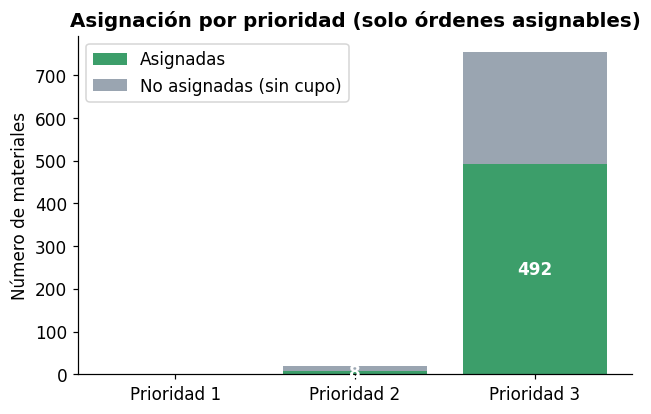

In [42]:
# Asignadas por prioridad (df_asig) vs asignables totales (materiales)
asig_por_prio = df_asig["prioridad"].value_counts().sort_index()
tot_por_prio = materiales["prioridad"].value_counts().sort_index()
no_asig_por_prio = (tot_por_prio - asig_por_prio).fillna(tot_por_prio)

prios = sorted(tot_por_prio.index)
asig_vals = [asig_por_prio.get(p, 0) for p in prios]
noasig_vals = [no_asig_por_prio.get(p, 0) for p in prios]

fig, ax = plt.subplots(figsize=(6.5, 4))
etiquetas = [f"Prioridad {int(p)}" for p in prios]
ax.bar(etiquetas, asig_vals, label="Asignadas", color=VERDE)
ax.bar(etiquetas, noasig_vals, bottom=asig_vals, label="No asignadas (sin cupo)", color=GRIS)
ax.set_ylabel("Número de materiales")
ax.set_title("Asignación por prioridad (solo órdenes asignables)")
ax.legend()
for i, (a, n) in enumerate(zip(asig_vals, noasig_vals)):
    if a: ax.text(i, a/2, str(a), ha="center", va="center", color="white", fontweight="bold")
guardar(fig, "g4_asignacion_por_prioridad.png")
plt.show()

El modelo prioriza las órdenes de prioridad 3 (492 asignadas). Las que quedan fuera es por falta de capacidad, no por su valor.

Aprovechamiento de la capacidad en los talleres más cargados:

Guardado: graficos/g5_uso_capacidad.png


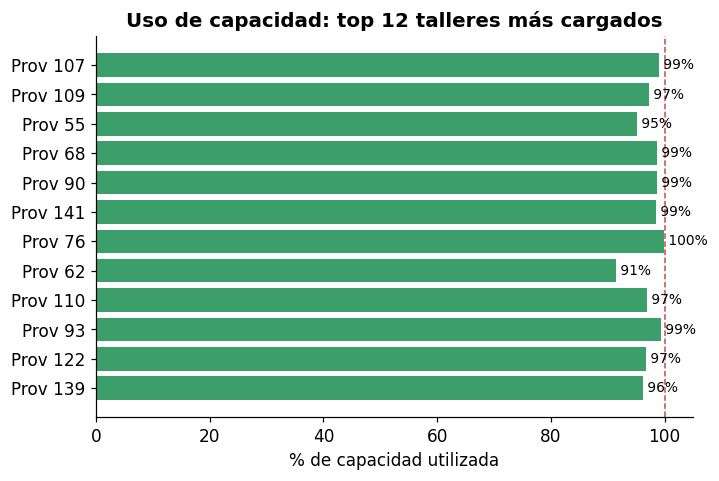

In [43]:
uso = df_asig.groupby("proveedor")["minutos"].sum().rename("usados").reset_index()
uso["cap"] = uso["proveedor"].map(cap_prov)
uso["pct"] = uso["usados"] / uso["cap"] * 100
top = uso.sort_values("usados", ascending=False).head(12)

fig, ax = plt.subplots(figsize=(7, 4.5))
barras = ax.barh([f"Prov {int(p)}" for p in top["proveedor"]][::-1], top["pct"][::-1],
                 color=[VERDE if v >= 90 else NARANJA for v in top["pct"][::-1]])
ax.set_xlabel("% de capacidad utilizada")
ax.set_title("Uso de capacidad: top 12 talleres más cargados")
ax.axvline(100, color=ROJO, ls="--", lw=1)
for b, v in zip(barras, top["pct"][::-1]):
    ax.text(v, b.get_y()+b.get_height()/2, f" {v:.0f}%", va="center", fontsize=9)
guardar(fig, "g5_uso_capacidad.png")
plt.show()

Los talleres que reciben trabajo quedan al 91-99% de su capacidad: el modelo aprovecha bien el espacio disponible de cada taller.

### 4.6 · Capacidad ociosa y fragmentación

El modelo deja un 28% de la capacidad sin usar. Analizamos por qué, con los datos reales de la
asignación.

In [44]:
# Capacidad usada por cada proveedor (de la solución óptima) y hueco libre restante
uso_real = df_asig.groupby("proveedor")["minutos"].sum().rename("usado")
cap_series = pd.Series(cap_prov, name="capacidad")

frag = pd.concat([cap_series, uso_real], axis=1).fillna(0.0)
frag["hueco_libre"] = frag["capacidad"] - frag["usado"]

orden_promedio = ordenes_asignables["minutos"].mean()
capacidad_ociosa = frag["hueco_libre"].sum()

print(f"Capacidad total        : {frag['capacidad'].sum():,.0f} min")
print(f"Capacidad usada        : {frag['usado'].sum():,.0f} min ({frag['usado'].sum()/frag['capacidad'].sum()*100:.1f}%)")
print(f"Capacidad OCIOSA       : {capacidad_ociosa:,.0f} min ({capacidad_ociosa/frag['capacidad'].sum()*100:.1f}%)")
print(f"Tamaño promedio de una orden: {orden_promedio:,.0f} min")
print()
print(f"Si la capacidad ociosa estuviera TODA junta, cabrían: "
      f"{capacidad_ociosa/orden_promedio:.0f} órdenes más (teórico).")

Capacidad total        : 1,948,185 min
Capacidad usada        : 1,395,417 min (71.6%)
Capacidad OCIOSA       : 552,768 min (28.4%)
Tamaño promedio de una orden: 4,124 min

Si la capacidad ociosa estuviera TODA junta, cabrían: 134 órdenes más (teórico).


In [45]:
# ¿Cuántos talleres tienen un hueco libre MENOR que una orden promedio? (hueco inútil)
hueco_sirve = (frag["hueco_libre"] >= orden_promedio).sum()
hueco_no_sirve = (frag["hueco_libre"] < orden_promedio).sum()
min_atrapados = frag.loc[frag["hueco_libre"] < orden_promedio, "hueco_libre"].sum()

print(f"Talleres cuyo hueco libre SÍ alcanza para 1 orden promedio: {hueco_sirve}")
print(f"Talleres cuyo hueco libre NO alcanza (fragmento inútil)    : {hueco_no_sirve}")
print(f"Minutos atrapados en huecos demasiado pequeños            : {min_atrapados:,.0f} "
      f"({min_atrapados/capacidad_ociosa*100:.0f}% de la capacidad ociosa)")
print()
print("=> La mayor parte de la capacidad ociosa está en huecos más pequeños que una orden:")
print("   existe, pero NO es utilizable sin partir órdenes (lo que la regla prohíbe).")

Talleres cuyo hueco libre SÍ alcanza para 1 orden promedio: 32
Talleres cuyo hueco libre NO alcanza (fragmento inútil)    : 95
Minutos atrapados en huecos demasiado pequeños            : 143,657 (26% de la capacidad ociosa)

=> La mayor parte de la capacidad ociosa está en huecos más pequeños que una orden:
   existe, pero NO es utilizable sin partir órdenes (lo que la regla prohíbe).


Comparación del hueco libre de cada taller contra el tamaño de una orden promedio:

Gráfico guardado en graficos/g7_fragmentacion.png


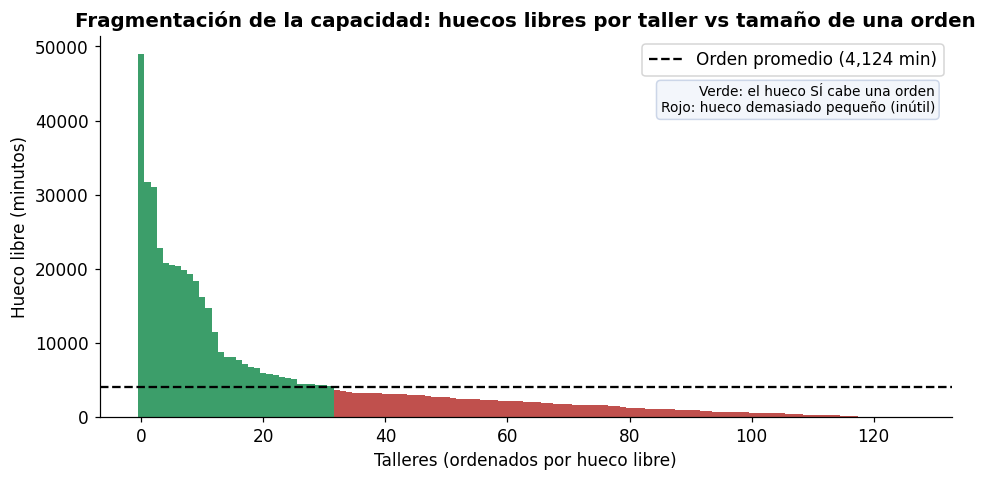

In [46]:
import matplotlib.pyplot as plt
from pathlib import Path
DIR_G = Path("graficos"); DIR_G.mkdir(exist_ok=True)

huecos_ordenados = frag["hueco_libre"].sort_values(ascending=False).values

fig, ax = plt.subplots(figsize=(10, 4.5))
colores = ["#3c9e6a" if h >= orden_promedio else "#c0504d" for h in huecos_ordenados]
ax.bar(range(len(huecos_ordenados)), huecos_ordenados, color=colores, width=1.0)
ax.axhline(orden_promedio, color="black", ls="--", lw=1.5,
           label=f"Orden promedio ({orden_promedio:,.0f} min)")
ax.set_xlabel("Talleres (ordenados por hueco libre)")
ax.set_ylabel("Hueco libre (minutos)")
ax.set_title("Fragmentación de la capacidad: huecos libres por taller vs tamaño de una orden")
ax.legend()
ax.text(0.98, 0.80, "Verde: el hueco SÍ cabe una orden\nRojo: hueco demasiado pequeño (inútil)",
        transform=ax.transAxes, ha="right", fontsize=9,
        bbox=dict(boxstyle="round", facecolor="#f3f6fb", edgecolor="#ccd6e8"))
fig.savefig(DIR_G/"g7_fragmentacion.png", bbox_inches="tight", dpi=130)
print("Gráfico guardado en graficos/g7_fragmentacion.png")
plt.show()

La mayoría de los talleres tienen un hueco libre menor que una orden promedio (barras rojas): la
capacidad ociosa queda partida en pedazos demasiado pequeños. Como la regla de material completo no
permite partir órdenes, esos huecos no se pueden rellenar. No es un fallo del modelo, sino un problema
de empaquetado (bin packing).

---
# Fase 5 · Secuenciación de la producción

Para cada taller con órdenes asignadas, se decide el orden de producción con la regla WSPT (ordenar
por prioridad dividida por tiempo), que minimiza de forma óptima el tiempo de entrega ponderado por
prioridad.

### 5.1 · Secuencia óptima por proveedor

In [47]:
# Trabajamos sobre las asignaciones de la Fase 4
secuencia = df_asig[["proveedor", "Material", "tipo_elegible", "minutos", "prioridad"]].copy()

# Ratio WSPT = prioridad / tiempo de procesamiento (mayor ratio => se produce antes)
secuencia["ratio_wspt"] = secuencia["prioridad"] / secuencia["minutos"]

# Ordenar DENTRO de cada proveedor por ratio descendente
secuencia = secuencia.sort_values(["proveedor", "ratio_wspt"],
                                   ascending=[True, False]).reset_index(drop=True)

# Posición en la cola y tiempo de finalización acumulado por proveedor
secuencia["posicion"] = secuencia.groupby("proveedor").cumcount() + 1
secuencia["tiempo_finalizacion"] = secuencia.groupby("proveedor")["minutos"].cumsum()

print("Secuenciación construida para", secuencia["proveedor"].nunique(), "proveedores")
print(f"Total de órdenes secuenciadas: {len(secuencia)}")

Secuenciación construida para 95 proveedores
Total de órdenes secuenciadas: 500


### 5.2 · Ejemplo: la cola de un proveedor

In [48]:
# Elegimos un proveedor con suficientes órdenes para ilustrar
conteo = secuencia.groupby("proveedor").size().sort_values(ascending=False)
prov_ejemplo = conteo.index[0]

cola = secuencia[secuencia["proveedor"] == prov_ejemplo]
print(f"Secuencia de producción del proveedor {prov_ejemplo} ({len(cola)} órdenes):")
print(cola[["posicion", "Material", "tipo_elegible", "prioridad", "minutos",
            "ratio_wspt", "tiempo_finalizacion"]].to_string(index=False))

Secuencia de producción del proveedor 107 (57 órdenes):
 posicion  Material tipo_elegible  prioridad  minutos  ratio_wspt  tiempo_finalizacion
        1   2693082  PUNTO BASICO       3.00   469.16        0.01               469.16
        2   2690908  PUNTO BASICO       3.00   471.34        0.01               940.50
        3   2691275  PUNTO BASICO       3.00   646.68        0.00             1,587.18
        4   2691411  PUNTO BASICO       3.00   670.96        0.00             2,258.14
        5   2690708  PUNTO BASICO       3.00   704.62        0.00             2,962.76
        6   2691077  PUNTO BASICO       3.00   708.90        0.00             3,671.66
        7   2691409  PUNTO BASICO       3.00   755.28        0.00             4,426.94
        8   2691374  PUNTO BASICO       3.00   759.85        0.00             5,186.79
        9   2692577  PUNTO BASICO       3.00   769.02        0.00             5,955.81
       10   2690762  PUNTO BASICO       3.00   800.35        0.00         

### 5.3 · Indicadores de la secuenciación

In [49]:
# Tiempo de finalización promedio por nivel de prioridad
resumen_sec = (secuencia.groupby("prioridad")
               .agg(n_ordenes=("Material", "size"),
                    pos_media=("posicion", "mean"),
                    finaliz_media=("tiempo_finalizacion", "mean"))
               .sort_index(ascending=False))
print("Tiempo de finalización medio por prioridad (menor = sale antes):")
print(resumen_sec.to_string())

# Indicador global: suma de tiempos de finalización ponderados por prioridad
objetivo_wspt = (secuencia["prioridad"] * secuencia["tiempo_finalizacion"]).sum()
print(f"\nObjetivo total (Σ prioridad × tiempo_finalización): {objetivo_wspt:,.0f}")
print("(Este es el valor que la regla WSPT minimiza de forma óptima por proveedor.)")

Tiempo de finalización medio por prioridad (menor = sale antes):
           n_ordenes  pos_media  finaliz_media
prioridad                                     
3.00             492       9.75      16,001.65
2.00               8       4.38      17,308.68

Objetivo total (Σ prioridad × tiempo_finalización): 23,895,374
(Este es el valor que la regla WSPT minimiza de forma óptima por proveedor.)


---
# Fase 6 · Escenarios What-if

El modelo se encapsula en una función reutilizable para simular distintas decisiones de negocio
cambiando sus parámetros, y comparar su efecto sobre el resultado.

### 6.1 · El modelo como función reutilizable

In [50]:
import pulp
from collections import defaultdict

def resolver_asignacion(w_prio=0.50, w_clas=0.25, w_exp=0.25,
                        pesos_clasif=None, homologar_trafico=True,
                        capacidad_override=None, tiempo_limite=20, gap=0.02,
                        etiqueta="escenario"):
    """Resuelve la asignación óptima con los parámetros dados y devuelve un dict de resultados.

    - w_prio, w_clas, w_exp : pesos de la función de valor.
    - pesos_clasif          : dict categoría->peso (por defecto el PESO_CLASIFICACION global).
    - homologar_trafico     : si True, variantes TRAFICO usan su tipo base.
    - capacidad_override    : dict {ID: nueva_capacidad} para simular liberar capacidad.
    - tiempo_limite, gap    : control del solver.
    """
    pesos_clasif = pesos_clasif or PESO_CLASIFICACION

    # --- Capacidad (con override opcional) ---
    cap_base = dict(zip(capacidad["ID"], capacidad["capacidad"]))
    if capacidad_override:
        cap_base.update(capacidad_override)
    cap_pos = {pid: c for pid, c in cap_base.items() if c > 0}

    # --- Homologación (recalcular tipo_elegible según el flag) ---
    tipos_prov = set(proveedores["tipo_producto"].unique())
    def hom(tp):
        if homologar_trafico and tp.endswith(" TRAFICO"):
            base = tp[:-len(" TRAFICO")].strip()
            if base in tipos_prov:
                return base
        return tp
    ords = ordenes.copy()
    ords["tipo_elegible"] = ords["tipo_producto"].apply(hom)

    # --- Proveedores elegibles por tipo (según capacidad vigente) ---
    pt = (proveedores.merge(pd.DataFrame({"ID": list(cap_pos)}), on="ID", how="inner")
          [["ID", "tipo_producto"]].drop_duplicates())
    prov_por_tipo_e = pt.groupby("tipo_producto")["ID"].apply(list).to_dict()

    tipos_cubiertos = set(pt["tipo_producto"])
    asignables = ords[ords["tipo_elegible"].isin(tipos_cubiertos)].copy()

    # --- Score de importancia (según pesos_clasif) ---
    max_peso = max(pesos_clasif.values())
    clasif_n = {r.ID: pesos_clasif.get(r.clasificacion, 0) / max_peso
                for r in proveedores[["ID", "clasificacion"]].drop_duplicates(subset="ID").itertuples()}

    # --- Valor por par ---
    PMIN, PMAX = ords["prioridad"].min(), ords["prioridad"].max()
    def pnorm(p): return (p - PMIN) / (PMAX - PMIN) if PMAX > PMIN else 1.0
    mins = dict(zip(ords["Material"], ords["minutos"]))

    pares = []
    for r in asignables.itertuples():
        tp = r.tipo_elegible
        for p in prov_por_tipo_e.get(tp, []):
            v = (w_prio * pnorm(r.prioridad)
                 + w_clas * clasif_n.get(p, 0.0)
                 + w_exp * exp_norm.get((p, tp), 0.0))
            pares.append((r.Material, p, v))

    # --- Modelo ---
    modelo = pulp.LpProblem(etiqueta, pulp.LpMaximize)
    xv = {(m, p): pulp.LpVariable(f"x_{m}_{p}", cat="Binary") for m, p, _ in pares}
    modelo += pulp.lpSum(v * xv[(m, p)] for m, p, v in pares)
    bym, byp = defaultdict(list), defaultdict(list)
    for m, p, _ in pares:
        bym[m].append(xv[(m, p)]); byp[p].append((mins[m], xv[(m, p)]))
    for m, vs in bym.items():
        modelo += pulp.lpSum(vs) <= 1
    for p, vs in byp.items():
        modelo += pulp.lpSum(a * b for a, b in vs) <= cap_pos[p]
    modelo.solve(pulp.PULP_CBC_CMD(msg=False, timeLimit=tiempo_limite, gapRel=gap))

    asign = [(m, p) for (m, p) in xv if xv[(m, p)].value() == 1]
    df_a = pd.DataFrame(asign, columns=["Material", "proveedor"]).merge(
        asignables[["Material", "minutos", "prioridad"]], on="Material")
    return {
        "etiqueta": etiqueta,
        "estado": pulp.LpStatus[modelo.status],
        "valor": pulp.value(modelo.objective),
        "asignadas": len(df_a),
        "asignables": len(asignables),
        "min_usados": df_a["minutos"].sum(),
        "cap_total": sum(cap_pos.values()),
        "p3_asignadas": int((df_a["prioridad"] == 3).sum()),
        "df": df_a,
    }

print("Función resolver_asignacion() lista.")

Función resolver_asignacion() lista.


### 6.2 · Escenario base

In [51]:
r_base = resolver_asignacion(etiqueta="BASE")
print(f"[{r_base['etiqueta']}] estado={r_base['estado']} | "
      f"asignadas={r_base['asignadas']}/{r_base['asignables']} | "
      f"min usados={r_base['min_usados']:,.0f} | P3={r_base['p3_asignadas']}")

[BASE] estado=Optimal | asignadas=500/775 | min usados=1,395,417 | P3=492


### 6.3 · Escenarios alternativos

Se comparan tres decisiones: dar más peso a la experiencia, dar más peso a la importancia del
proveedor, y liberar capacidad a los talleres bloqueados.

In [52]:
# Escenario 1: favorecer experiencia
r_exp = resolver_asignacion(w_prio=0.40, w_clas=0.15, w_exp=0.45, etiqueta="EXPERIENCIA")

# Escenario 2: favorecer clasificación (proveedores importantes)
r_clas = resolver_asignacion(w_prio=0.40, w_clas=0.45, w_exp=0.15, etiqueta="CLASIFICACION")

# Escenario 3: liberar capacidad a los proveedores bloqueados de los tipos huérfanos
#   (damos 50.000 min a un proveedor de cada tipo huérfano para ver cuánto se rescata)
override = {69: 50000, 60: 50000, 38: 50000, 2: 50000}
r_cap = resolver_asignacion(capacidad_override=override, etiqueta="LIBERAR_CAPACIDAD")

for r in (r_exp, r_clas, r_cap):
    print(f"[{r['etiqueta']:>16}] estado={r['estado']} | "
          f"asignadas={r['asignadas']} | min usados={r['min_usados']:,.0f} | P3={r['p3_asignadas']}")

[     EXPERIENCIA] estado=Optimal | asignadas=499 | min usados=1,385,704 | P3=491
[   CLASIFICACION] estado=Optimal | asignadas=498 | min usados=1,391,344 | P3=489
[LIBERAR_CAPACIDAD] estado=Optimal | asignadas=545 | min usados=1,625,235 | P3=534


### 6.4 · Comparación de escenarios

In [53]:
comparacion = pd.DataFrame([
    {"Escenario": r["etiqueta"],
     "Órdenes asignadas": r["asignadas"],
     "Órdenes P3": r["p3_asignadas"],
     "Minutos usados": round(r["min_usados"]),
     "Uso capacidad %": round(r["min_usados"] / r["cap_total"] * 100, 1),
     "Valor objetivo": round(r["valor"], 2)}
    for r in [r_base, r_exp, r_clas, r_cap]
])
print("COMPARACIÓN DE ESCENARIOS WHAT-IF:")
print(comparacion.to_string(index=False))

COMPARACIÓN DE ESCENARIOS WHAT-IF:
        Escenario  Órdenes asignadas  Órdenes P3  Minutos usados  Uso capacidad %  Valor objetivo
             BASE                500         492         1395417            71.60          401.80
      EXPERIENCIA                499         491         1385704            71.10          367.61
    CLASIFICACION                498         489         1391344            71.40          396.65
LIBERAR_CAPACIDAD                545         534         1625235            75.70          430.27


In [54]:
# Efecto concreto de liberar capacidad vs base
rescatadas = r_cap["asignadas"] - r_base["asignadas"]
print("Efecto de liberar capacidad a los talleres bloqueados:")
print(f"  Órdenes asignadas BASE            : {r_base['asignadas']}")
print(f"  Órdenes asignadas LIBERAR_CAPACIDAD: {r_cap['asignadas']}")
print(f"  Órdenes adicionales rescatadas     : {rescatadas}")

Efecto de liberar capacidad a los talleres bloqueados:
  Órdenes asignadas BASE            : 500
  Órdenes asignadas LIBERAR_CAPACIDAD: 545
  Órdenes adicionales rescatadas     : 45


Efecto de cada escenario sobre el total de órdenes entregadas:

Guardado: graficos/g6_escenarios.png


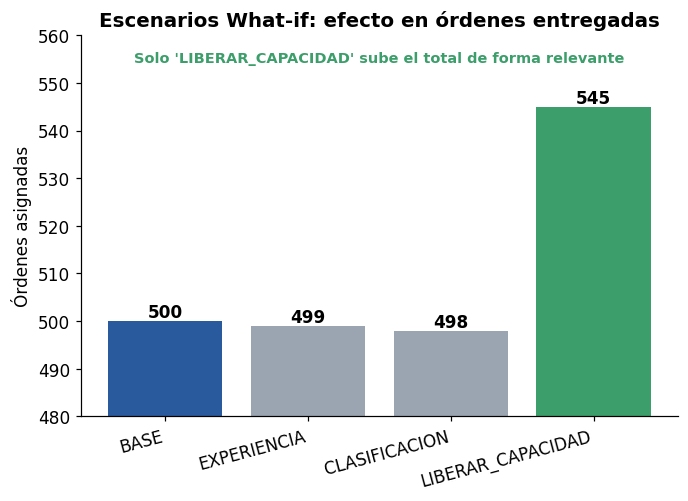

In [55]:
escen = comparacion.set_index("Escenario")["Órdenes asignadas"]

fig, ax = plt.subplots(figsize=(7, 4.5))
colores = [AZUL, GRIS, GRIS, VERDE]
barras = ax.bar(escen.index, escen.values, color=colores)
ax.set_ylabel("Órdenes asignadas")
ax.set_title("Escenarios What-if: efecto en órdenes entregadas")
ax.set_ylim(480, max(escen.values) + 15)
for b, v in zip(barras, escen.values):
    ax.text(b.get_x()+b.get_width()/2, v, str(int(v)), ha="center", va="bottom", fontweight="bold")
plt.xticks(rotation=15, ha="right")
ax.text(0.5, 0.93, "Solo 'LIBERAR_CAPACIDAD' sube el total de forma relevante",
        transform=ax.transAxes, ha="center", color=VERDE, fontsize=9.5, fontweight="bold")
guardar(fig, "g6_escenarios.png")
plt.show()

Cambiar los pesos (EXPERIENCIA, CLASIFICACION) casi no mueve el total. Solo liberar capacidad lo sube de forma relevante: el cuello de botella es la capacidad, no los criterios de asignación.

### 6.5 · Conclusiones del What-if

- El problema está sobre-demandado: la demanda supera la capacidad en un 74%, por lo que es necesario
  elegir qué producir. El modelo prioriza correctamente las órdenes más importantes.
- Ajustar los pesos de la función de valor reordena a qué proveedores se asigna el trabajo, pero casi
  no cambia el total de órdenes entregadas: el factor limitante es la capacidad.
- Liberar capacidad a los talleres bloqueados sí aumenta el total entregado. La palanca de negocio más
  efectiva para producir más es ampliar la capacidad, no afinar los criterios de asignación.

---
# Fase 7 · Pipeline reproducible
Agrupo todo el análisis en funciones para poder repetirlo de principio a fin con una sola llamada, y
que sea fácil de reutilizar con otros datos.

### 7.1 · Funciones del pipeline

In [ ]:
def cargar_datos(carpeta):
    carpeta = Path(carpeta)
    return {
        "ordenes": pd.read_csv(carpeta / "Ordenes_de_trabajo.csv"),
        "proveedores": pd.read_csv(carpeta / "Lista_de_proveedores.csv"),
        "historial": pd.read_csv(carpeta / "Historial_de_ordenes.csv"),
        "capacidad": pd.read_csv(carpeta / "Capacidad_de_proveedores.csv"),
    }


def preparar_datos(datos, pesos_clasif, homologar_trafico=True, modo_exp="total_a_cada_tipo"):
    ordenes = datos["ordenes"].copy()
    proveedores = datos["proveedores"].copy()
    historial = datos["historial"].copy()
    capacidad = datos["capacidad"].copy()

    # Normalizar texto y quitar duplicados
    for d in (ordenes, proveedores):
        d["Denominacion Tipo de producto"] = d["Denominacion Tipo de producto"].str.strip().str.upper()
    proveedores = proveedores.drop_duplicates().reset_index(drop=True)
    proveedores = proveedores.rename(columns={"Descripcion clasificacion proveedor": "clasificacion",
                                              "Denominacion Tipo de producto": "tipo_producto"})
    ordenes = ordenes.rename(columns={"Denominacion Tipo de producto": "tipo_producto",
                                      "Minutos totales de la orden": "minutos",
                                      "Prioridad": "prioridad", "Unidades de la OP": "unidades"})
    capacidad = capacidad.rename(columns={"Capacidad Disponible": "capacidad"})

    # Homologación TRAFICO
    tipos_prov = set(proveedores["tipo_producto"].unique())
    def hom(tp):
        if homologar_trafico and tp.endswith(" TRAFICO"):
            base = tp[:-len(" TRAFICO")].strip()
            if base in tipos_prov:
                return base
        return tp
    ordenes["tipo_elegible"] = ordenes["tipo_producto"].apply(hom)

    # Elegibilidad (capacidad > 0)
    cap_pos = capacidad[capacidad["capacidad"] > 0][["ID", "capacidad"]]
    prov_tipo = (proveedores.merge(cap_pos, on="ID", how="inner")
                 [["ID", "clasificacion", "tipo_producto"]].drop_duplicates())
    sin_cobertura = set(ordenes["tipo_elegible"].unique()) - set(prov_tipo["tipo_producto"].unique())
    asignables = ordenes[~ordenes["tipo_elegible"].isin(sin_cobertura)].copy()

    # Experiencia por (proveedor, tipo)
    prod_total = historial.groupby("ID")["Unidades fabricadas"].sum()
    filas = []
    for pid, tipos in prov_tipo.groupby("ID")["tipo_producto"].apply(list).items():
        total = float(prod_total.get(pid, 0.0)); n = len(tipos)
        for tp in tipos:
            val = total / n if (modo_exp == "proporcional_igual" and n > 1) else total
            filas.append({"ID": pid, "tipo_producto": tp, "experiencia": val})
    exp = pd.DataFrame(filas)
    exp["experiencia_norm"] = (exp["experiencia"] /
                               exp.groupby("tipo_producto")["experiencia"].transform("max")).fillna(0.0)

    # Importancia del proveedor
    clasif = proveedores[["ID", "clasificacion"]].drop_duplicates(subset="ID").copy()
    mx = max(pesos_clasif.values())
    clasif["clasif_norm"] = clasif["clasificacion"].map(pesos_clasif) / mx

    return {"asignables": asignables, "prov_tipo": prov_tipo, "experiencia": exp,
            "clasif": clasif, "cap_pos": cap_pos, "sin_cobertura": sin_cobertura}


def asignar(prep, w_prio=0.5, w_clas=0.25, w_exp=0.25, tiempo=60, gap=0.01):
    """Paso 3 — Resuelve el modelo de optimización y devuelve las asignaciones (material -> proveedor)."""
    import pulp
    from collections import defaultdict

    asignables = prep["asignables"]
    materiales = (asignables.groupby(["Material", "tipo_elegible"])
                  .agg(minutos=("minutos", "sum"), prioridad=("prioridad", "max")).reset_index())
    pmin, pmax = asignables["prioridad"].min(), asignables["prioridad"].max()
    materiales["prio_norm"] = materiales["prioridad"].apply(
        lambda p: (p - pmin) / (pmax - pmin) if pmax > pmin else 1.0)

    minutos_mat = dict(zip(materiales["Material"], materiales["minutos"]))
    tipo_mat = dict(zip(materiales["Material"], materiales["tipo_elegible"]))
    prio_mat = dict(zip(materiales["Material"], materiales["prio_norm"]))
    cap_prov = dict(zip(prep["cap_pos"]["ID"], prep["cap_pos"]["capacidad"]))
    clasif_n = dict(zip(prep["clasif"]["ID"], prep["clasif"]["clasif_norm"]))
    exp_n = {(r.ID, r.tipo_producto): r.experiencia_norm for r in prep["experiencia"].itertuples()}
    prov_por_tipo = prep["prov_tipo"].groupby("tipo_producto")["ID"].apply(list).to_dict()

    pares = []
    for m in materiales["Material"]:
        tp = tipo_mat[m]
        for p in prov_por_tipo.get(tp, []):
            v = w_prio * prio_mat[m] + w_clas * clasif_n.get(p, 0) + w_exp * exp_n.get((p, tp), 0)
            pares.append((m, p, v))

    modelo = pulp.LpProblem("Asignacion", pulp.LpMaximize)
    xv = {(m, p): pulp.LpVariable(f"x_{m}_{p}", cat="Binary") for m, p, _ in pares}
    modelo += pulp.lpSum(v * xv[(m, p)] for m, p, v in pares)
    bym, byp = defaultdict(list), defaultdict(list)
    for m, p, _ in pares:
        bym[m].append(xv[(m, p)]); byp[p].append((minutos_mat[m], xv[(m, p)]))
    for m, vs in bym.items():
        modelo += pulp.lpSum(vs) <= 1
    for p, vs in byp.items():
        modelo += pulp.lpSum(a * b for a, b in vs) <= cap_prov[p]
    modelo.solve(pulp.PULP_CBC_CMD(msg=False, timeLimit=tiempo, gapRel=gap))

    asig = [(m, p) for (m, p) in xv if xv[(m, p)].value() == 1]
    df = pd.DataFrame(asig, columns=["Material", "proveedor"]).merge(
        materiales[["Material", "tipo_elegible", "minutos", "prioridad"]], on="Material")
    return {"estado": pulp.LpStatus[modelo.status], "valor": pulp.value(modelo.objective), "asignacion": df}


def secuenciar(asignacion):
    """Paso 4 — Ordena la producción de cada proveedor con la regla WSPT (prioridad / tiempo)."""
    sec = asignacion.copy()
    sec["ratio_wspt"] = sec["prioridad"] / sec["minutos"]
    sec = sec.sort_values(["proveedor", "ratio_wspt"], ascending=[True, False]).reset_index(drop=True)
    sec["posicion"] = sec.groupby("proveedor").cumcount() + 1
    sec["tiempo_finalizacion"] = sec.groupby("proveedor")["minutos"].cumsum()
    return sec

print("Funciones del pipeline definidas: cargar_datos, preparar_datos, asignar, secuenciar.")

Funciones del pipeline definidas: cargar_datos, preparar_datos, asignar, secuenciar.


### 7.2 · Ejecución del pipeline completo

Todo el flujo del análisis, de principio a fin, en pocas líneas:

In [57]:
# Flujo completo del pipeline
datos_pl   = cargar_datos(CARPETA_DATOS)
prep_pl    = preparar_datos(datos_pl, PESO_CLASIFICACION,
                            homologar_trafico=HOMOLOGAR_TRAFICO,
                            modo_exp=MODO_EXPERIENCIA_MULTITIPO)
res_pl     = asignar(prep_pl, w_prio=W_PRIORIDAD, w_clas=W_CLASIFICACION, w_exp=W_EXPERIENCIA)
secuencia_pl = secuenciar(res_pl["asignacion"])

print("===== RESULTADO DEL PIPELINE =====")
print(f"Estado del solver        : {res_pl['estado']}")
print(f"Materiales asignados     : {len(res_pl['asignacion'])}")
print(f"Minutos de producción    : {res_pl['asignacion']['minutos'].sum():,.0f}")
print(f"Órdenes secuenciadas     : {len(secuencia_pl)}")
print()
print("El pipeline reproduce el análisis completo con una sola secuencia de llamadas,")
print("y puede re-ejecutarse sobre datos nuevos cambiando únicamente la carpeta de entrada.")

===== RESULTADO DEL PIPELINE =====
Estado del solver        : Optimal
Materiales asignados     : 500
Minutos de producción    : 1,395,417
Órdenes secuenciadas     : 500

El pipeline reproduce el análisis completo con una sola secuencia de llamadas,
y puede re-ejecutarse sobre datos nuevos cambiando únicamente la carpeta de entrada.
